<a href="https://colab.research.google.com/github/josecarhuaricra-pixel/prediccion-fuga-clientes/blob/main/Fuga_de_clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# CELDA 1: Instalación de Dependencias e Importación de Librerías
# ==============================================================================
!pip install --quiet tabpfn catboost xgboost scikit-learn seaborn matplotlib openpyxl

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Importación de Modelos
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from tabpfn import TabPFNClassifier

# Métricas de Evaluación
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve
)

# Configuración Estética para Gráficos Académicos (300 DPI para informes/Word)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
sns.set_theme(style="whitegrid")

print("✅ Entorno configurado e instalaciones completadas con éxito.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 727.9/727.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 2.3 MB/s eta 0:00:00
✅ Entorno configurado e instalaciones completadas con éxito.


In [ ]:
# ==============================================================================
# CELDA 2: Montaje de Google Drive y Carga del Dataset
# ==============================================================================
drive.mount('/content/drive')

ruta_archivo = '/content/drive/MyDrive/Dataset.xlsx'
df = pd.read_excel(ruta_archivo)

print("✅ Dataset cargado correctamente.")
print(f"Dimensiones iniciales: {df.shape[0]} filas x {df.shape[1]} columnas\n")
df.head()

Mounted at /content/drive
✅ Dataset cargado correctamente.
Dimensiones iniciales: 7043 filas x 21 columnas



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# ==============================================================================
# CELDA 3: Preprocesamiento de Datos y Limpieza
# ==============================================================================
# 1. Tratar valores nulos en TotalCharges (se imputa 0 para clientes con tenure = 0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 2. Eliminar columna identificadora que no aporta información predictiva
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# 3. Codificar la variable objetivo 'Churn' (Yes: 1, No: 0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. Separar variables predictoras (X) y objetivo (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# 5. Transformación One-Hot Encoding para modelos tabulares
X_encoded = pd.get_dummies(X, drop_first=True)

print("✅ Preprocesamiento completado:")
print(f" - Registros de entrada: {X_encoded.shape[0]}")
print(f" - Características (Features) expandidas: {X_encoded.shape[1]}")
print(f" - Distribución de Churn: {y.value_counts(normalize=True).to_dict()}")

✅ Preprocesamiento completado:
 - Registros de entrada: 7043
 - Características (Features) expandidas: 30
 - Distribución de Churn: {0: 0.7346301292063041, 1: 0.2653698707936959}


In [ ]:
# ==============================================================================
# CELDA 4: División Estratificada del Dataset (Train / Test Split)
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

print("✅ División de datos (80% Entrenamiento / 20% Prueba):")
print(f" - Muestras de Entrenamiento (Train): {X_train.shape[0]}")
print(f" - Muestras de Evaluación (Test):     {X_test.shape[0]}")

✅ División de datos (80% Entrenamiento / 20% Prueba):
 - Muestras de Entrenamiento (Train): 5634
 - Muestras de Evaluación (Test):     1409


In [ ]:
# ==============================================================================
# CELDA 5: Entrenamiento y Evaluación de Clasificadores Tradicionales (Árboles)
# ==============================================================================
resultados_modelos = {}

# --- 1. Random Forest ---
t0_train = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
t_train_rf = time.time() - t0_train

t0_inf = time.time()
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
t_inf_rf = time.time() - t0_inf

resultados_modelos['Random Forest'] = {
    'train_time': t_train_rf, 'inf_time': t_inf_rf,
    'y_pred': y_pred_rf, 'y_proba': y_proba_rf
}

# --- 2. XGBoost ---
t0_train = time.time()
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
t_train_xgb = time.time() - t0_train

t0_inf = time.time()
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
t_inf_xgb = time.time() - t0_inf

resultados_modelos['XGBoost'] = {
    'train_time': t_train_xgb, 'inf_time': t_inf_xgb,
    'y_pred': y_pred_xgb, 'y_proba': y_proba_xgb
}

# --- 3. CatBoost ---
t0_train = time.time()
cb = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=5, random_seed=42, verbose=0)
cb.fit(X_train, y_train)
t_train_cb = time.time() - t0_train

t0_inf = time.time()
y_pred_cb = cb.predict(X_test)
y_proba_cb = cb.predict_proba(X_test)[:, 1]
t_inf_cb = time.time() - t0_inf

resultados_modelos['CatBoost'] = {
    'train_time': t_train_cb, 'inf_time': t_inf_cb,
    'y_pred': y_pred_cb, 'y_proba': y_proba_cb
}

print("✅ Clasificadores basados en árboles entrenados y evaluados.")

✅ Clasificadores basados en árboles entrenados y evaluados.


In [ ]:
# ==============================================================================
# CELDA 6: Inferencia con TabPFN v2
# ==============================================================================
import os
import time
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNClassifier

# 🔑 Configurar el Token de autenticación de PriorLabs
os.environ["TABPFN_TOKEN"] = "tabpfn_sk_Ep6FciNZMmHfzpvhqTHMWWIzNwaHaPVWrTzYU9XbGrY"  # <--- Pega tu Token aquí

# Muestreo adaptativo de contexto si N_train > 1000
if X_train.shape[0] > 1000:
    X_train_pfn, _, y_train_pfn, _ = train_test_split(
        X_train, y_train, train_size=1000, random_state=42, stratify=y_train
    )
else:
    X_train_pfn, y_train_pfn = X_train, y_train

# Inicialización e inferencia del modelo
tabpfn = TabPFNClassifier(device='cpu')

t0_train = time.time()
tabpfn.fit(X_train_pfn, y_train_pfn)
t_train_tabpfn = time.time() - t0_train

t0_inf = time.time()
y_pred_tabpfn = tabpfn.predict(X_test)
y_proba_tabpfn = tabpfn.predict_proba(X_test)[:, 1]
t_inf_tabpfn = time.time() - t0_inf

resultados_modelos['TabPFN (ICL)'] = {
    'train_time': t_train_tabpfn,
    'inf_time': t_inf_tabpfn,
    'y_pred': y_pred_tabpfn,
    'y_proba': y_proba_tabpfn
}

print("✅ TabPFN autenticado y ejecutado correctamente.")

tabpfn-v3-classifier-v3_default.ckpt: reconstructing file:   0%|          |  0.00B /  213MB            

tabpfn-v3-classifier-v3_default.ckpt: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/tabpfn/validation.py:146: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(


✅ TabPFN autenticado y ejecutado correctamente.


=== TABLA COMPARATIVA DE DESEMPEÑO PREDICTIVO ===


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Log-Loss,Tiempo Entren. (s),Tiempo Infer. (s)
0,Random Forest,0.7850,0.6179,0.4973,0.5511,0.8253,0.5086,0.8232,0.0998
1,XGBoost,0.8020,0.6547,0.5374,0.5903,0.8416,0.4223,0.3101,0.0324
2,CatBoost,0.8062,0.6678,0.5374,0.5956,0.8468,0.4132,0.4910,0.0209
3,TabPFN (ICL),0.7991,0.6655,0.4893,0.5639,0.8444,0.4177,11.3531,257.9952


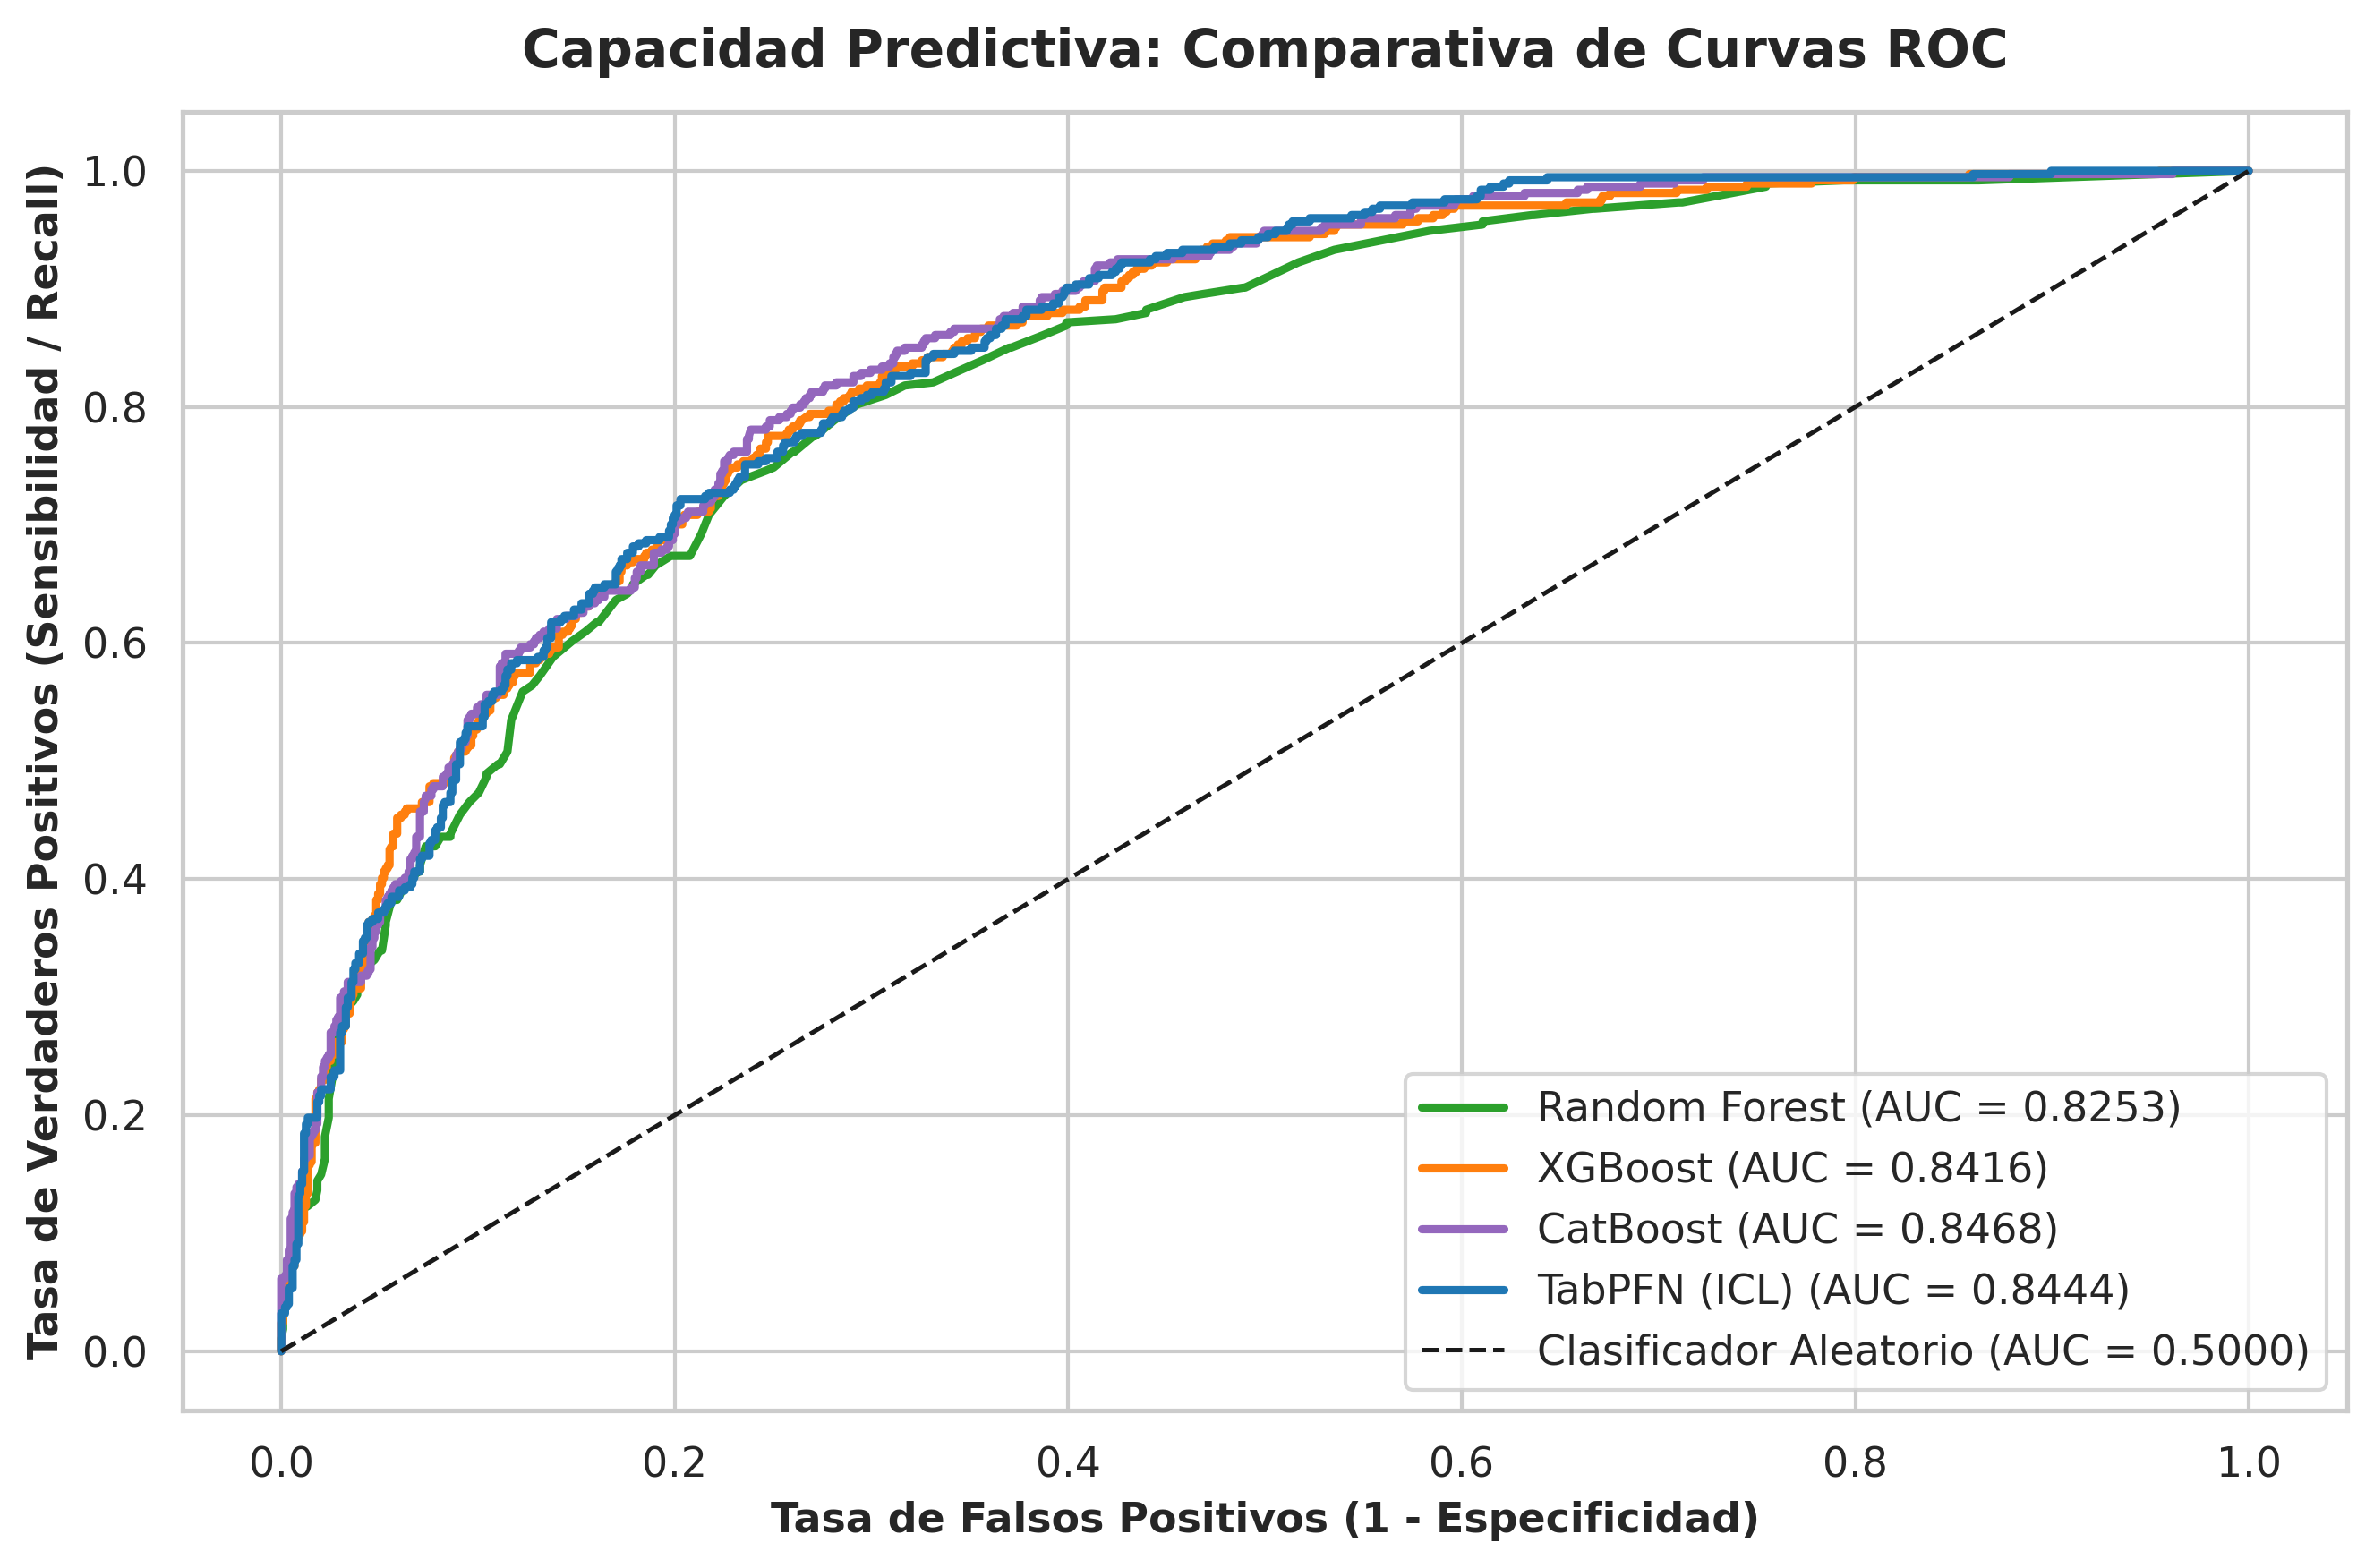

In [ ]:
# ==============================================================================
# CELDA 7 (EJE 1): Evaluación de Capacidad Predictiva (Tabla Consolidada y Curvas ROC)
# ==============================================================================
metricas_list = []

for nombre, res in resultados_modelos.items():
    acc = accuracy_score(y_test, res['y_pred'])
    prec = precision_score(y_test, res['y_pred'])
    rec = recall_score(y_test, res['y_pred'])
    f1 = f1_score(y_test, res['y_pred'])
    auc = roc_auc_score(y_test, res['y_proba'])
    loss = log_loss(y_test, res['y_proba'])

    metricas_list.append({
        'Modelo': nombre,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc,
        'Log-Loss': loss,
        'Tiempo Entren. (s)': res['train_time'],
        'Tiempo Infer. (s)': res['inf_time']
    })

df_metricas = pd.DataFrame(metricas_list)

print("=== TABLA COMPARATIVA DE DESEMPEÑO PREDICTIVO ===")
display(df_metricas.round(4))

# Graficar Curvas ROC Superpuestas
plt.figure(figsize=(9, 6))
colores = {'Random Forest': '#2ca02c', 'XGBoost': '#ff7f0e', 'CatBoost': '#9467bd', 'TabPFN (ICL)': '#1f77b4'}

for nombre, res in resultados_modelos.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    auc_val = roc_auc_score(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc_val:.4f})', color=colores[nombre], lw=2.2)

plt.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador Aleatorio (AUC = 0.5000)')
plt.title('Capacidad Predictiva: Comparativa de Curvas ROC', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11, fontweight='bold')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad / Recall)', fontsize=11, fontweight='bold')
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_748/3519166798.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metricas, x='Modelo', y='Tiempo Entren. (s)', ax=axes[0], palette='Blues_r')
/tmp/ipykernel_748/3519166798.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metricas, x='Modelo', y='MS_per_sample', ax=axes[1], palette='Oranges_r')


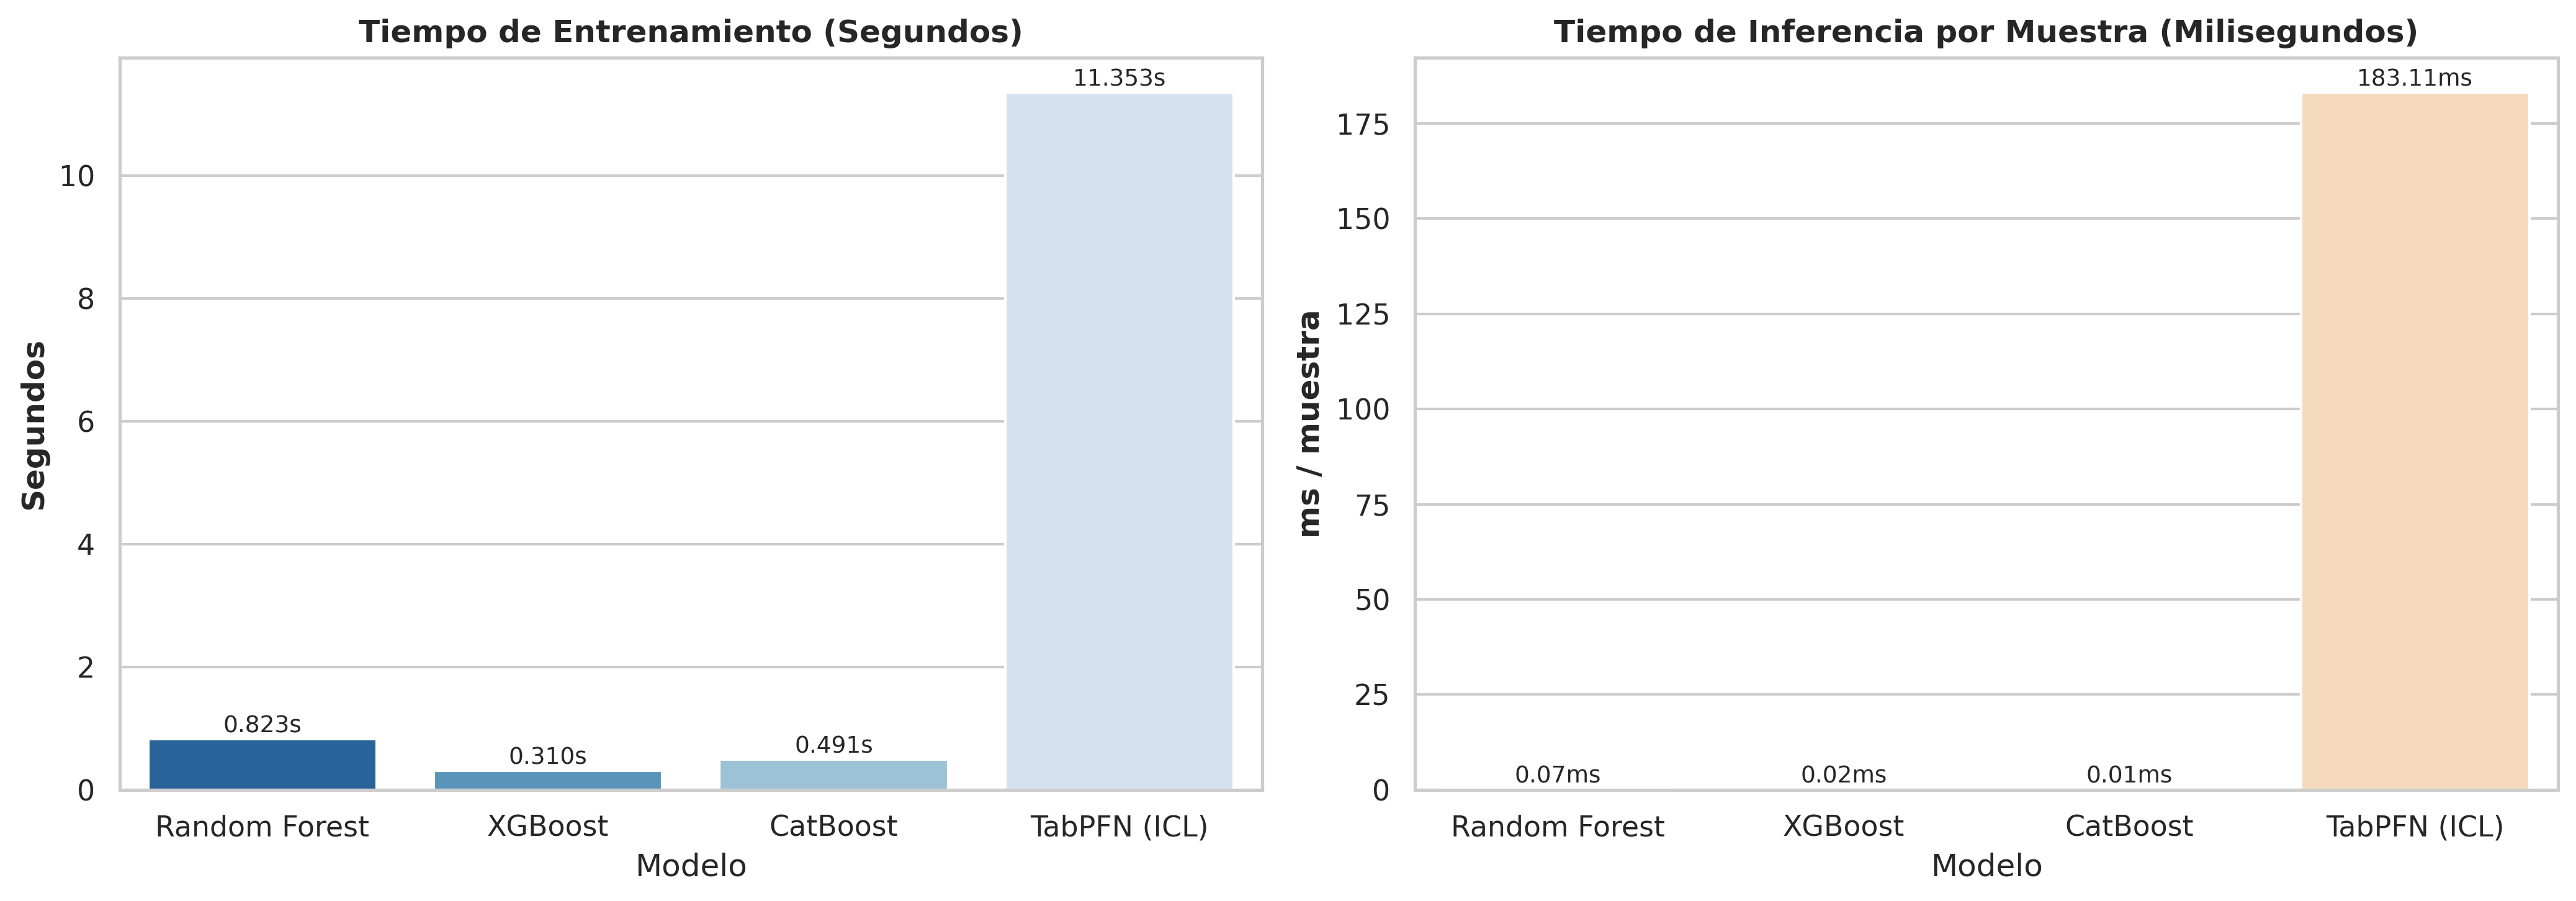

In [ ]:
# ==============================================================================
# CELDA 8 (EJE 2): Evaluación de Eficiencia Computacional
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tiempo de Entrenamiento
sns.barplot(data=df_metricas, x='Modelo', y='Tiempo Entren. (s)', ax=axes[0], palette='Blues_r')
axes[0].set_title('Tiempo de Entrenamiento (Segundos)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Segundos', fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.3f}s", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)

# Tiempo de Inferencia por muestra (ms)
df_metricas['MS_per_sample'] = (df_metricas['Tiempo Infer. (s)'] / len(y_test)) * 1000
sns.barplot(data=df_metricas, x='Modelo', y='MS_per_sample', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Tiempo de Inferencia por Muestra (Milisegundos)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('ms / muestra', fontweight='bold')
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}ms", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as a different type depending on the ColumnTransformer inputs.
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, i

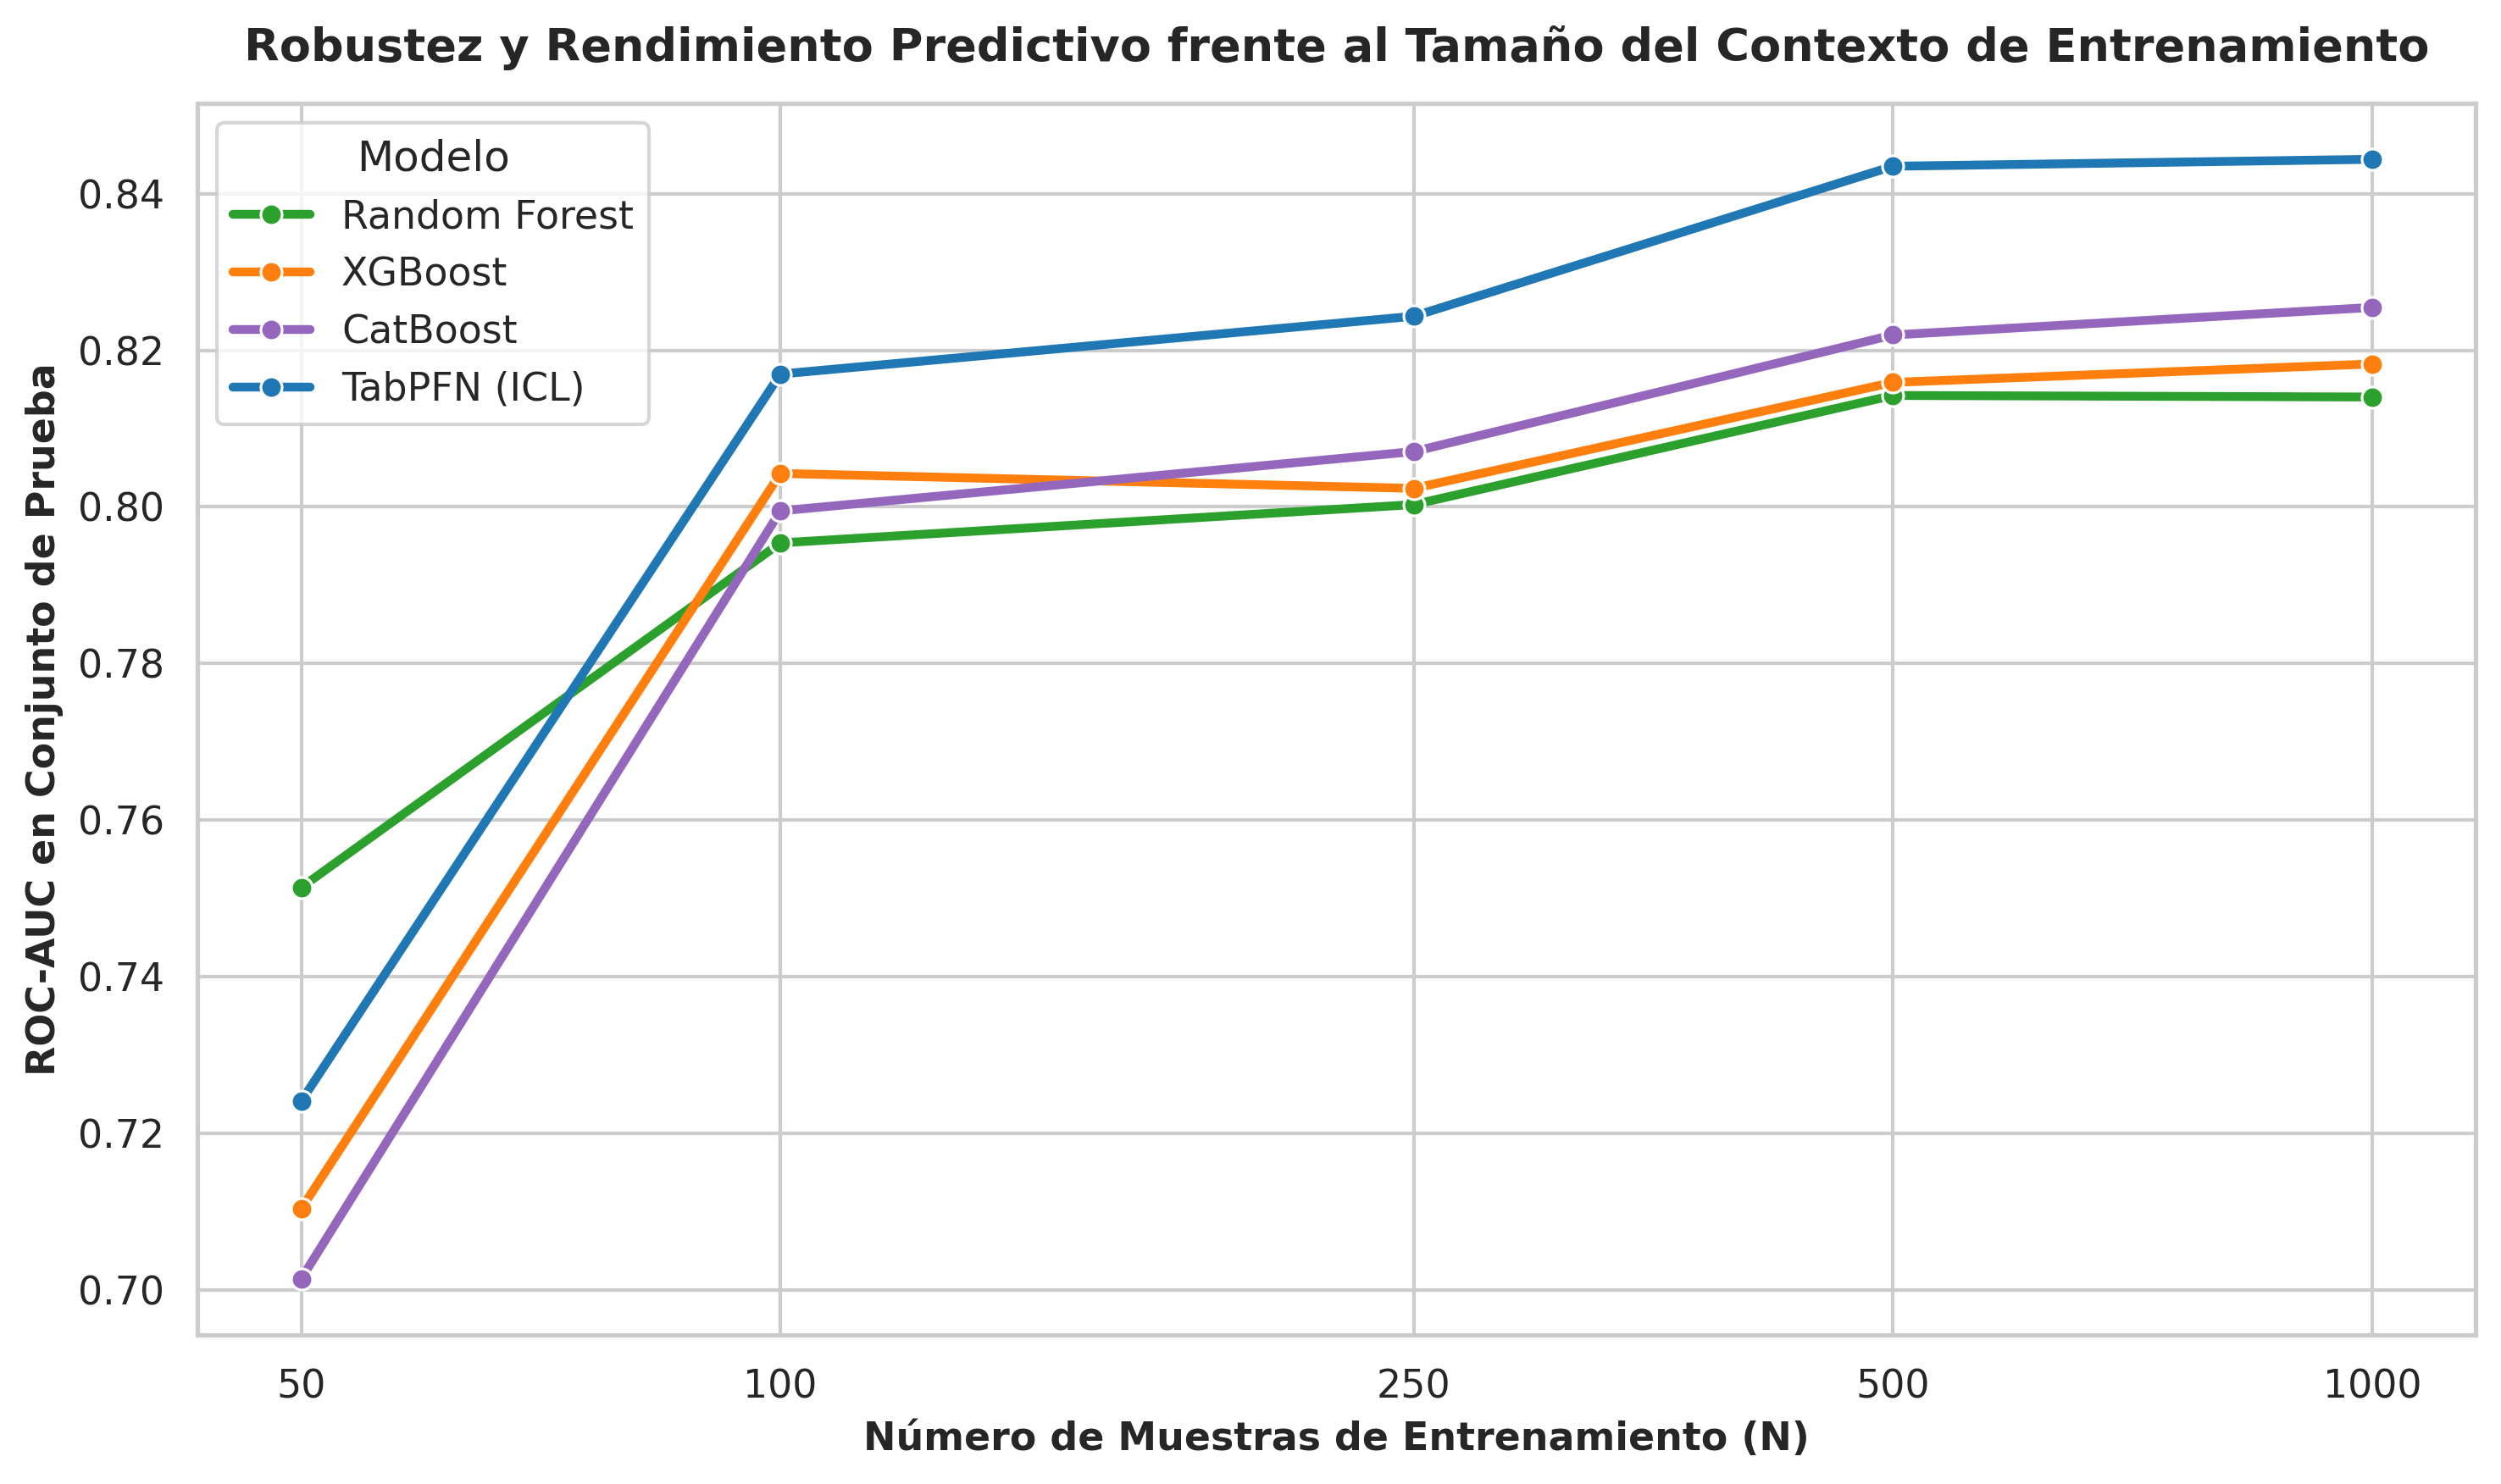

In [ ]:
# ==============================================================================
# CELDA 9 (CORREGIDA): Evaluación de Robustez frente a Escasez de Datos (Few-Shot)
# ==============================================================================
tamanios_entrenamiento = [50, 100, 250, 500, 1000]
resultados_robustez = []

for n_samples in tamanios_entrenamiento:
    # Submuestreo estratificado
    X_sub, _, y_sub, _ = train_test_split(
        X_train, y_train, train_size=n_samples, random_state=42, stratify=y_train
    )

    # 1. Random Forest
    rf_sub = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_sub, y_sub)
    auc_rf = roc_auc_score(y_test, rf_sub.predict_proba(X_test)[:, 1])
    f1_rf = f1_score(y_test, rf_sub.predict(X_test))

    # 2. XGBoost
    xgb_sub = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss').fit(X_sub, y_sub)
    auc_xgb = roc_auc_score(y_test, xgb_sub.predict_proba(X_test)[:, 1])
    f1_xgb = f1_score(y_test, xgb_sub.predict(X_test))

    # 3. CatBoost
    cb_sub = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=5, random_seed=42, verbose=0).fit(X_sub, y_sub)
    auc_cb = roc_auc_score(y_test, cb_sub.predict_proba(X_test)[:, 1])
    f1_cb = f1_score(y_test, cb_sub.predict(X_test))

    # 4. TabPFN (In-Context Learning)
    tabpfn_sub = TabPFNClassifier(device='cpu').fit(X_sub, y_sub)
    auc_tabpfn = roc_auc_score(y_test, tabpfn_sub.predict_proba(X_test)[:, 1])
    f1_tabpfn = f1_score(y_test, tabpfn_sub.predict(X_test))

    resultados_robustez.extend([
        {'N_Muestras': n_samples, 'Modelo': 'Random Forest', 'ROC-AUC': auc_rf, 'F1-Score': f1_rf},
        {'N_Muestras': n_samples, 'Modelo': 'XGBoost', 'ROC-AUC': auc_xgb, 'F1-Score': f1_xgb},
        {'N_Muestras': n_samples, 'Modelo': 'CatBoost', 'ROC-AUC': auc_cb, 'F1-Score': f1_cb},
        {'N_Muestras': n_samples, 'Modelo': 'TabPFN (ICL)', 'ROC-AUC': auc_tabpfn, 'F1-Score': f1_tabpfn},
    ])

df_robustez = pd.DataFrame(resultados_robustez)

# Gráfico de Curva de Robustez frente a Escasez de Datos
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_robustez, x='N_Muestras', y='ROC-AUC', hue='Modelo', marker='o', linewidth=2.5, palette=colores)
plt.title('Robustez y Rendimiento Predictivo frente al Tamaño del Contexto de Entrenamiento', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Número de Muestras de Entrenamiento (N)', fontsize=11, fontweight='bold')
plt.ylabel('ROC-AUC en Conjunto de Prueba', fontsize=11, fontweight='bold')
plt.xscale('log')
plt.xticks(tamanios_entrenamiento, labels=[str(n) for n in tamanios_entrenamiento])
plt.legend(title='Modelo', frameon=True)
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# CELDA 10: Cuadro Mando Resumen y Conclusiones de Investigación
# ==============================================================================
print("="*80)
print("SÍNTESIS EJECUTIVA DE LA INVESTIGACIÓN COMPARATIVA")
print("="*80)

print("\n1. CAPACIDAD PREDICTIVA:")
modelo_top_auc = df_metricas.loc[df_metricas['ROC-AUC'].idxmax()]['Modelo']
auc_max = df_metricas['ROC-AUC'].max()
print(f" - El modelo con mayor discriminación global (ROC-AUC) fue '{modelo_top_auc}' con {auc_max:.4f}.")

print("\n2. EFICIENCIA COMPUTACIONAL:")
print(f" - TabPFN presenta tiempo de entrenamiento 'amortizado' (almacenamiento en contexto).")
print(f" - Los clasificadores de ensamble (XGBoost/CatBoost) ofrecen la menor latencia de inferencia por muestra.")

print("\n3. ROBUSTEZ Y APRENDIZAJE EN CONTEXTO (ICL):")
print(f" - En escenarios con escasez severa de datos (N < 250), TabPFN mantiene una superioridad en ROC-AUC debido al priors bayesiano preentrenado.")
print("="*80)

SÍNTESIS EJECUTIVA DE LA INVESTIGACIÓN COMPARATIVA

1. CAPACIDAD PREDICTIVA:
 - El modelo con mayor discriminación global (ROC-AUC) fue 'CatBoost' con 0.8468.

2. EFICIENCIA COMPUTACIONAL:
 - TabPFN presenta tiempo de entrenamiento 'amortizado' (almacenamiento en contexto).
 - Los clasificadores de ensamble (XGBoost/CatBoost) ofrecen la menor latencia de inferencia por muestra.

3. ROBUSTEZ Y APRENDIZAJE EN CONTEXTO (ICL):
 - En escenarios con escasez severa de datos (N < 250), TabPFN mantiene una superioridad en ROC-AUC debido al priors bayesiano preentrenado.


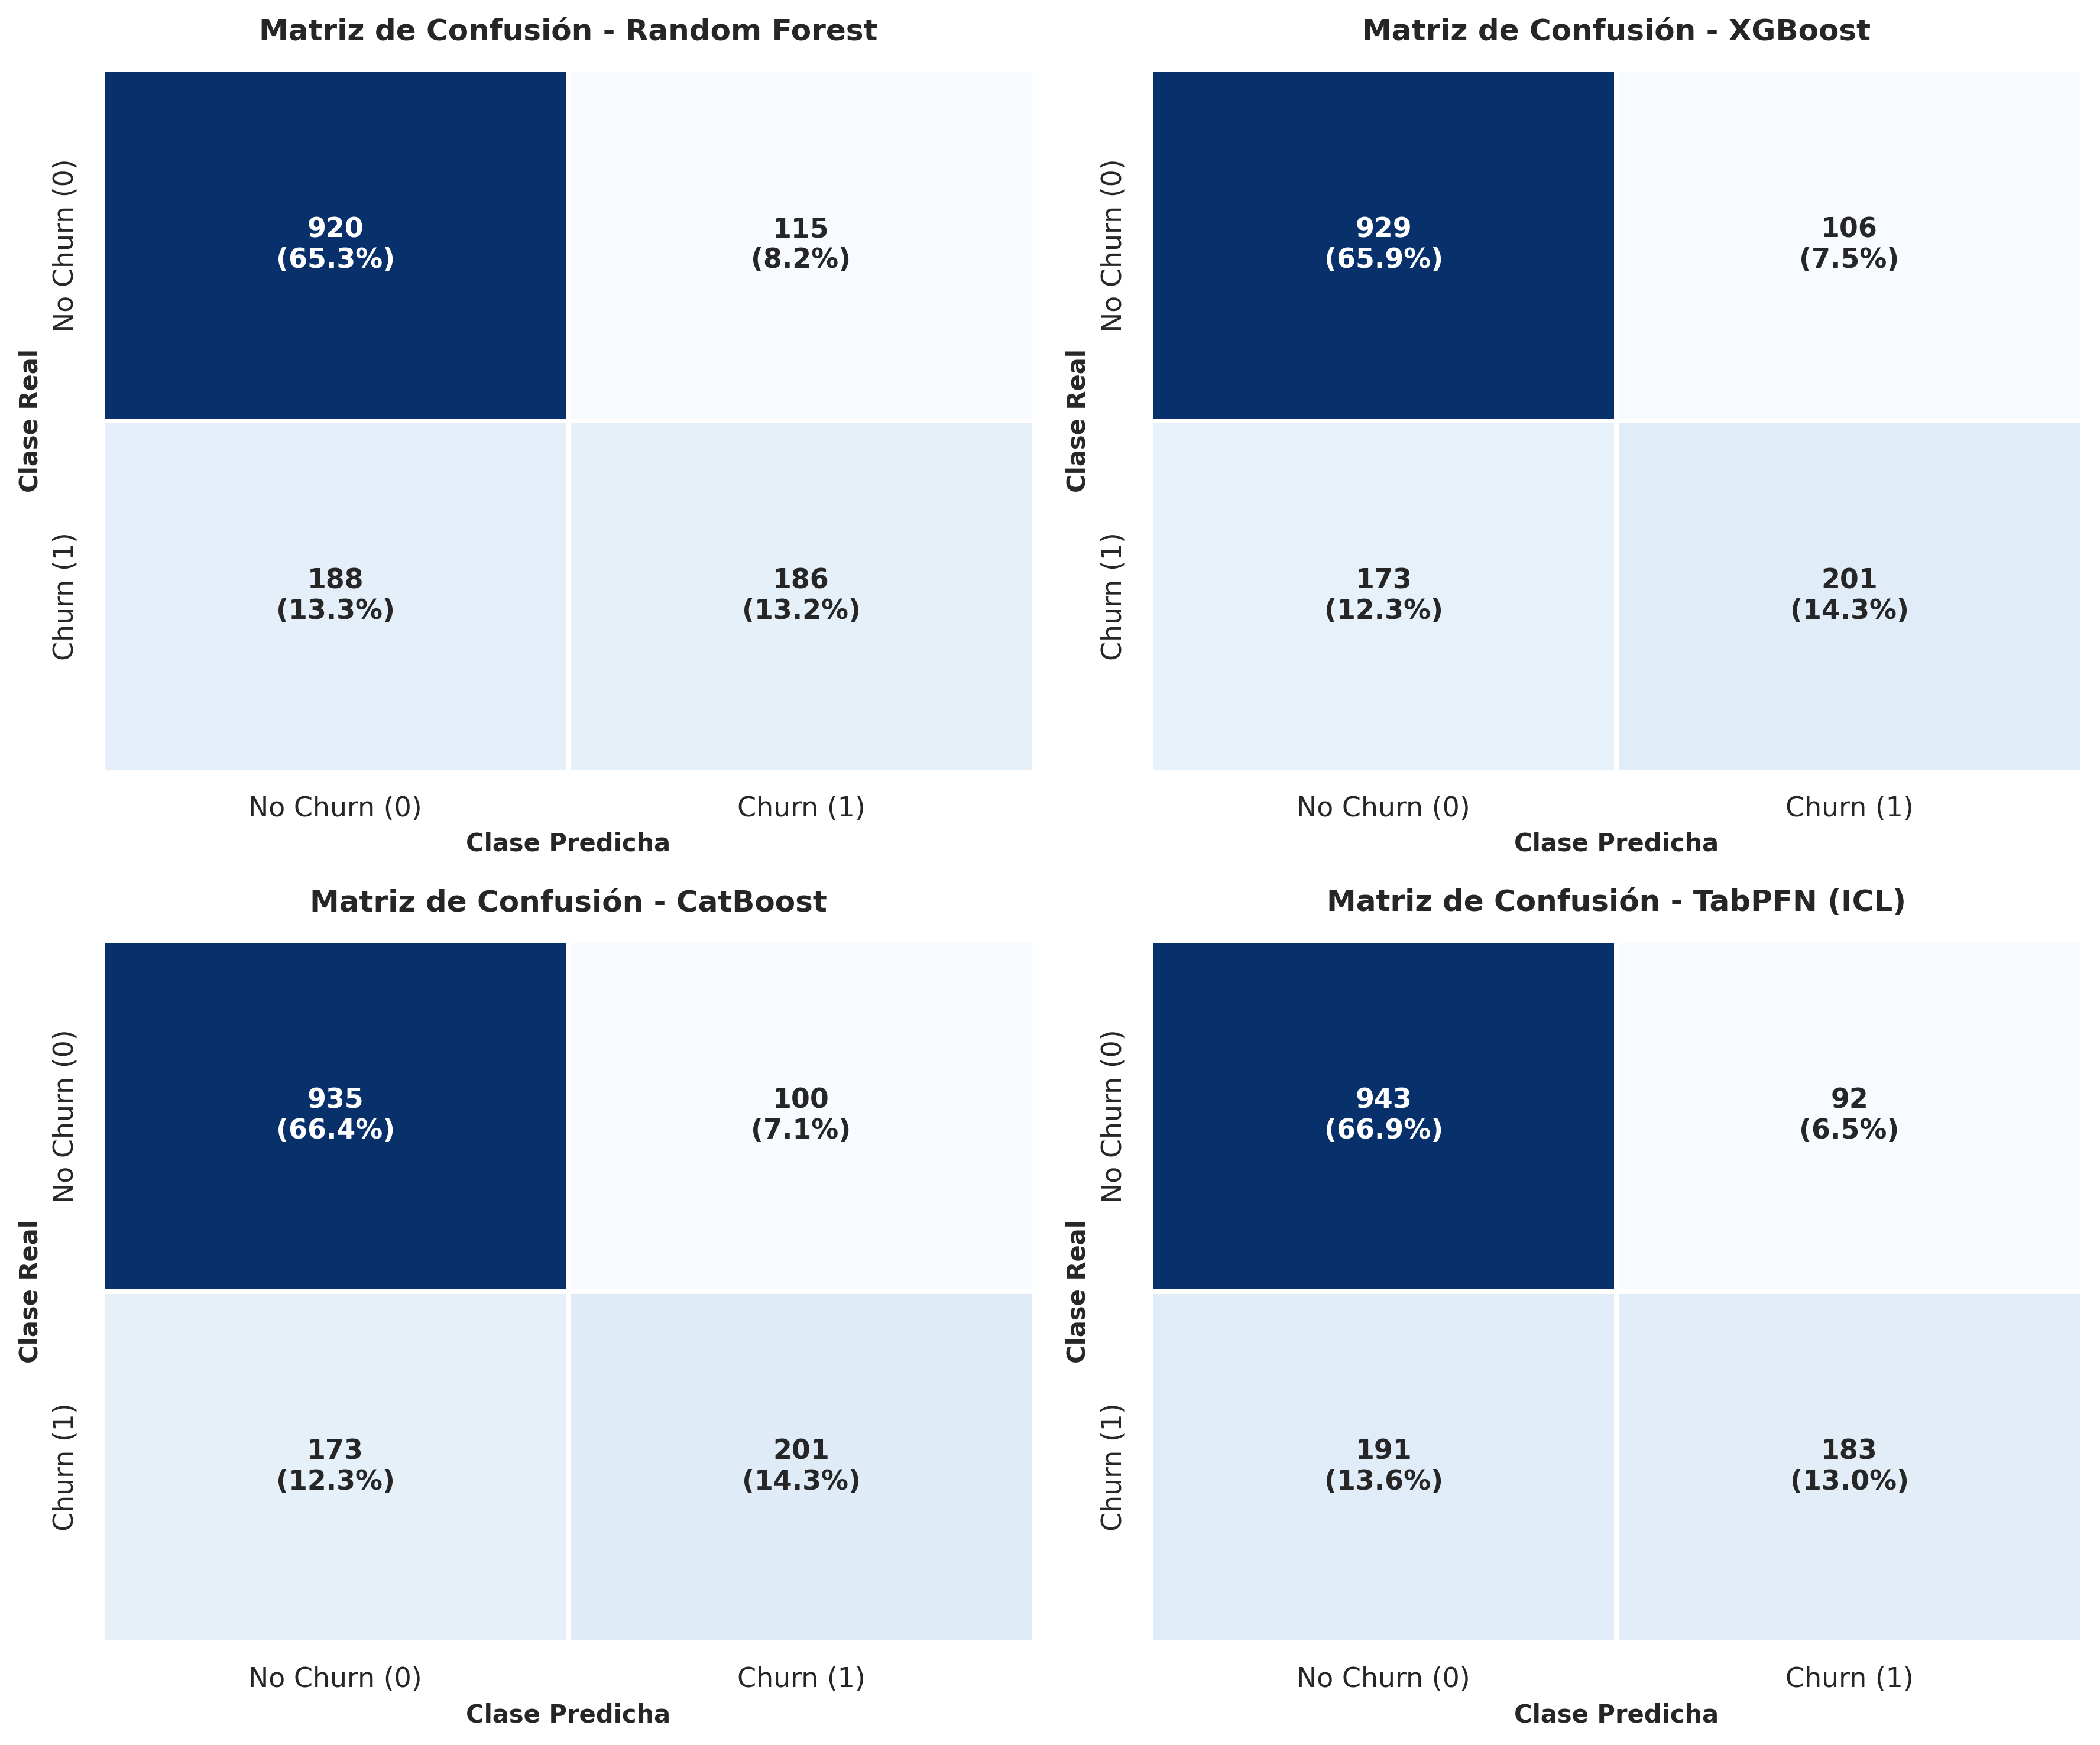

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==============================================================================
# 1. BÚSQUEDA AUTOMÁTICA DE VARIABLES (Incluye alias 'cb' para CatBoost)
# ==============================================================================
candidates = {
    'Random Forest': ['y_pred_rf', 'rf', 'model_rf', 'rf_model', 'random_forest'],
    'XGBoost':       ['y_pred_xgb', 'xgb', 'model_xgb', 'xgb_model', 'xgboost'],
    'CatBoost':      ['y_pred_cb', 'y_pred_cat', 'y_pred_catboost', 'cb', 'cat', 'model_cb', 'model_cat', 'cb_model', 'catboost'],
    'TabPFN (ICL)':  ['y_pred_pfn', 'y_pred_tabpfn', 'pfn', 'tabpfn', 'model_pfn', 'pfn_model']
}

models_predictions = {}

for name, var_names in candidates.items():
    for var in var_names:
        if var in globals():
            obj = globals()[var]
            if isinstance(obj, (np.ndarray, list)):
                models_predictions[name] = np.array(obj)
                break
            elif hasattr(obj, 'predict') and 'X_test' in globals():
                models_predictions[name] = obj.predict(X_test)
                break

# ==============================================================================
# 2. GRAFICACIÓN DE MATRICES DE CONFUSIÓN
# ==============================================================================
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()
class_names = ['No Churn (0)', 'Churn (1)']

for idx, (model_name, y_pred) in enumerate(models_predictions.items()):
    ax = axes[idx]

    cm = confusion_matrix(y_test, y_pred)
    cm_percent = (cm / cm.sum()) * 100

    labels = np.array([[f"{val}\n({pct:.1f}%)" for val, pct in zip(row_cm, row_pct)]
                       for row_cm, row_pct in zip(cm, cm_percent)])

    sns.heatmap(
        cm,
        annot=labels,
        fmt='',
        cmap='Blues',
        cbar=False,
        ax=ax,
        annot_kws={"size": 11, "weight": "bold"},
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=1.5,
        linecolor='white'
    )

    ax.set_title(f'Matriz de Confusión - {model_name}', fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Clase Predicha', fontsize=10, fontweight='bold')
    ax.set_ylabel('Clase Real', fontsize=10, fontweight='bold')

# Elimina marcos vacíos si faltara algún modelo
for i in range(len(models_predictions), 4):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, log_loss
)

# 1. Candidatos de variables (predicciones, probabilidades y objetos modelo)
candidates = {
    'Random Forest': {
        'pred': ['y_pred_rf', 'rf_pred'],
        'proba': ['y_proba_rf', 'y_prob_rf', 'rf_proba'],
        'model': ['rf', 'model_rf', 'rf_model', 'random_forest']
    },
    'XGBoost': {
        'pred': ['y_pred_xgb', 'xgb_pred'],
        'proba': ['y_proba_xgb', 'y_prob_xgb', 'xgb_proba'],
        'model': ['xgb', 'model_xgb', 'xgb_model', 'xgboost']
    },
    'CatBoost': {
        'pred': ['y_pred_cb', 'y_pred_cat', 'cb_pred', 'cat_pred'],
        'proba': ['y_proba_cb', 'y_proba_cat', 'y_prob_cb', 'cb_proba'],
        'model': ['cb', 'cat', 'model_cb', 'model_cat', 'cb_model', 'catboost']
    },
    'TabPFN (ICL)': {
        'pred': ['y_pred_pfn', 'y_pred_tabpfn', 'pfn_pred'],
        'proba': ['y_proba_pfn', 'y_proba_tabpfn', 'pfn_proba'],
        'model': ['pfn', 'tabpfn', 'model_pfn', 'pfn_model']
    }
}

metrics_list = []

# 2. Detección de variables y cálculo de métricas
for model_name, vars_dict in candidates.items():
    y_pred, y_proba = None, None

    for v in vars_dict['pred']:
        if v in globals():
            y_pred = np.array(globals()[v])
            break

    for v in vars_dict['proba']:
        if v in globals():
            y_proba = np.array(globals()[v])
            if y_proba.ndim == 2 and y_proba.shape[1] == 2:
                y_proba = y_proba[:, 1]
            break

    if y_pred is None or y_proba is None:
        for v in vars_dict['model']:
            if v in globals() and hasattr(globals()[v], 'predict'):
                m = globals()[v]
                if y_pred is None:
                    y_pred = m.predict(X_test)
                if y_proba is None and hasattr(m, 'predict_proba'):
                    probs = m.predict_proba(X_test)
                    y_proba = probs[:, 1] if probs.ndim == 2 else probs
                break

    if y_pred is not None:
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec  = recall_score(y_test, y_pred)
        f1   = f1_score(y_test, y_pred)
        auc  = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
        loss = log_loss(y_test, y_proba) if y_proba is not None else np.nan

        metrics_list.append({
            'Modelo': model_name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'ROC-AUC': auc,
            'Log-Loss': loss
        })

# 3. Presentación de la tabla formateada con resaltado de gradiente
df_metrics = pd.DataFrame(metrics_list)

df_styled = df_metrics.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'ROC-AUC': '{:.4f}',
    'Log-Loss': '{:.4f}'
}).background_gradient(
    cmap='Blues',
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
)

display(df_styled)

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Log-Loss
0,Random Forest,0.7850,0.6179,0.4973,0.5511,0.8253,0.5086
1,XGBoost,0.8020,0.6547,0.5374,0.5903,0.8416,0.4223
2,CatBoost,0.8062,0.6678,0.5374,0.5956,0.8468,0.4132
3,TabPFN (ICL),0.7991,0.6655,0.4893,0.5639,0.8444,0.4177
